<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 4.2: Attention Mechanism</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **The Bottleneck Problem in Sequence-to-Sequence Models**

Neural Machine Translation (NMT) uses an encoder-decoder architecture to translate text from one language to another.

**The Problem:**

In the basic seq2seq setup, the encoder processes the entire source sentence (e.g., "il a m' entarté" in French) and compresses all information into a single fixed-size vector. This vector is then passed to the decoder to generate the target sentence (e.g., "he hit me with a pie" in English).

**Why is this a bottleneck?**

The single encoding vector must capture *everything* about the source sentence, meaning, structure, word relationships, and context. For long or complex sentences, cramming all this information into one fixed-size representation becomes a serious limitation. Important details can be lost, leading to poor translations. Think of it like trying to summarize an entire book with just one sentence, you'll inevitably lose critical nuances.

<br>

***

### **The Soluation: Attention Mechanism**

**Core Idea:**

Instead of relying solely on one fixed encoding, attention allows the decoder to *look directly* at the encoder's hidden states at each decoding step. This way, the decoder can focus on different parts of the source sentence as needed.

**How it works:**

At each decoder timestep, attention computes a weighted combination of all encoder hidden states. The weights indicate which source words are most relevant for generating the current target word.

**Key Benefits:**

- **Solves the bottleneck:** The decoder has direct access to all source information, not just a compressed summary.
- **Handles long sentences better:** Information doesn't degrade as sentence length increases.
- **Provides interpretability:** By examining attention weights, we can see which source words the model focused on when generating each target word.
- **Mitigates vanishing gradients:** Creates shorter paths between distant parts of the sequence.

<br>

***

### **3. Attention Mechanism: Step-by-Step**

Let's walk through how attention works during decoding.

**Setup:**

- Encoder hidden states: $h_1, h_2, \dots, h_N \in \mathbb{R}^h$ (one for each source word)
- Decoder hidden state at timestep $t$: $s_t \in \mathbb{R}^h$

**Step 1: Compute Attention Scores**

For each encoder hidden state, compute how relevant it is to the current decoder state:

$$e^t = [s_t^T h_1, s_t^T h_2, \dots, s_t^T h_N] \in \mathbb{R}^N$$

Here, $s_t^T h_i$ is the dot product between the decoder state and each encoder state, a measure of similarity.

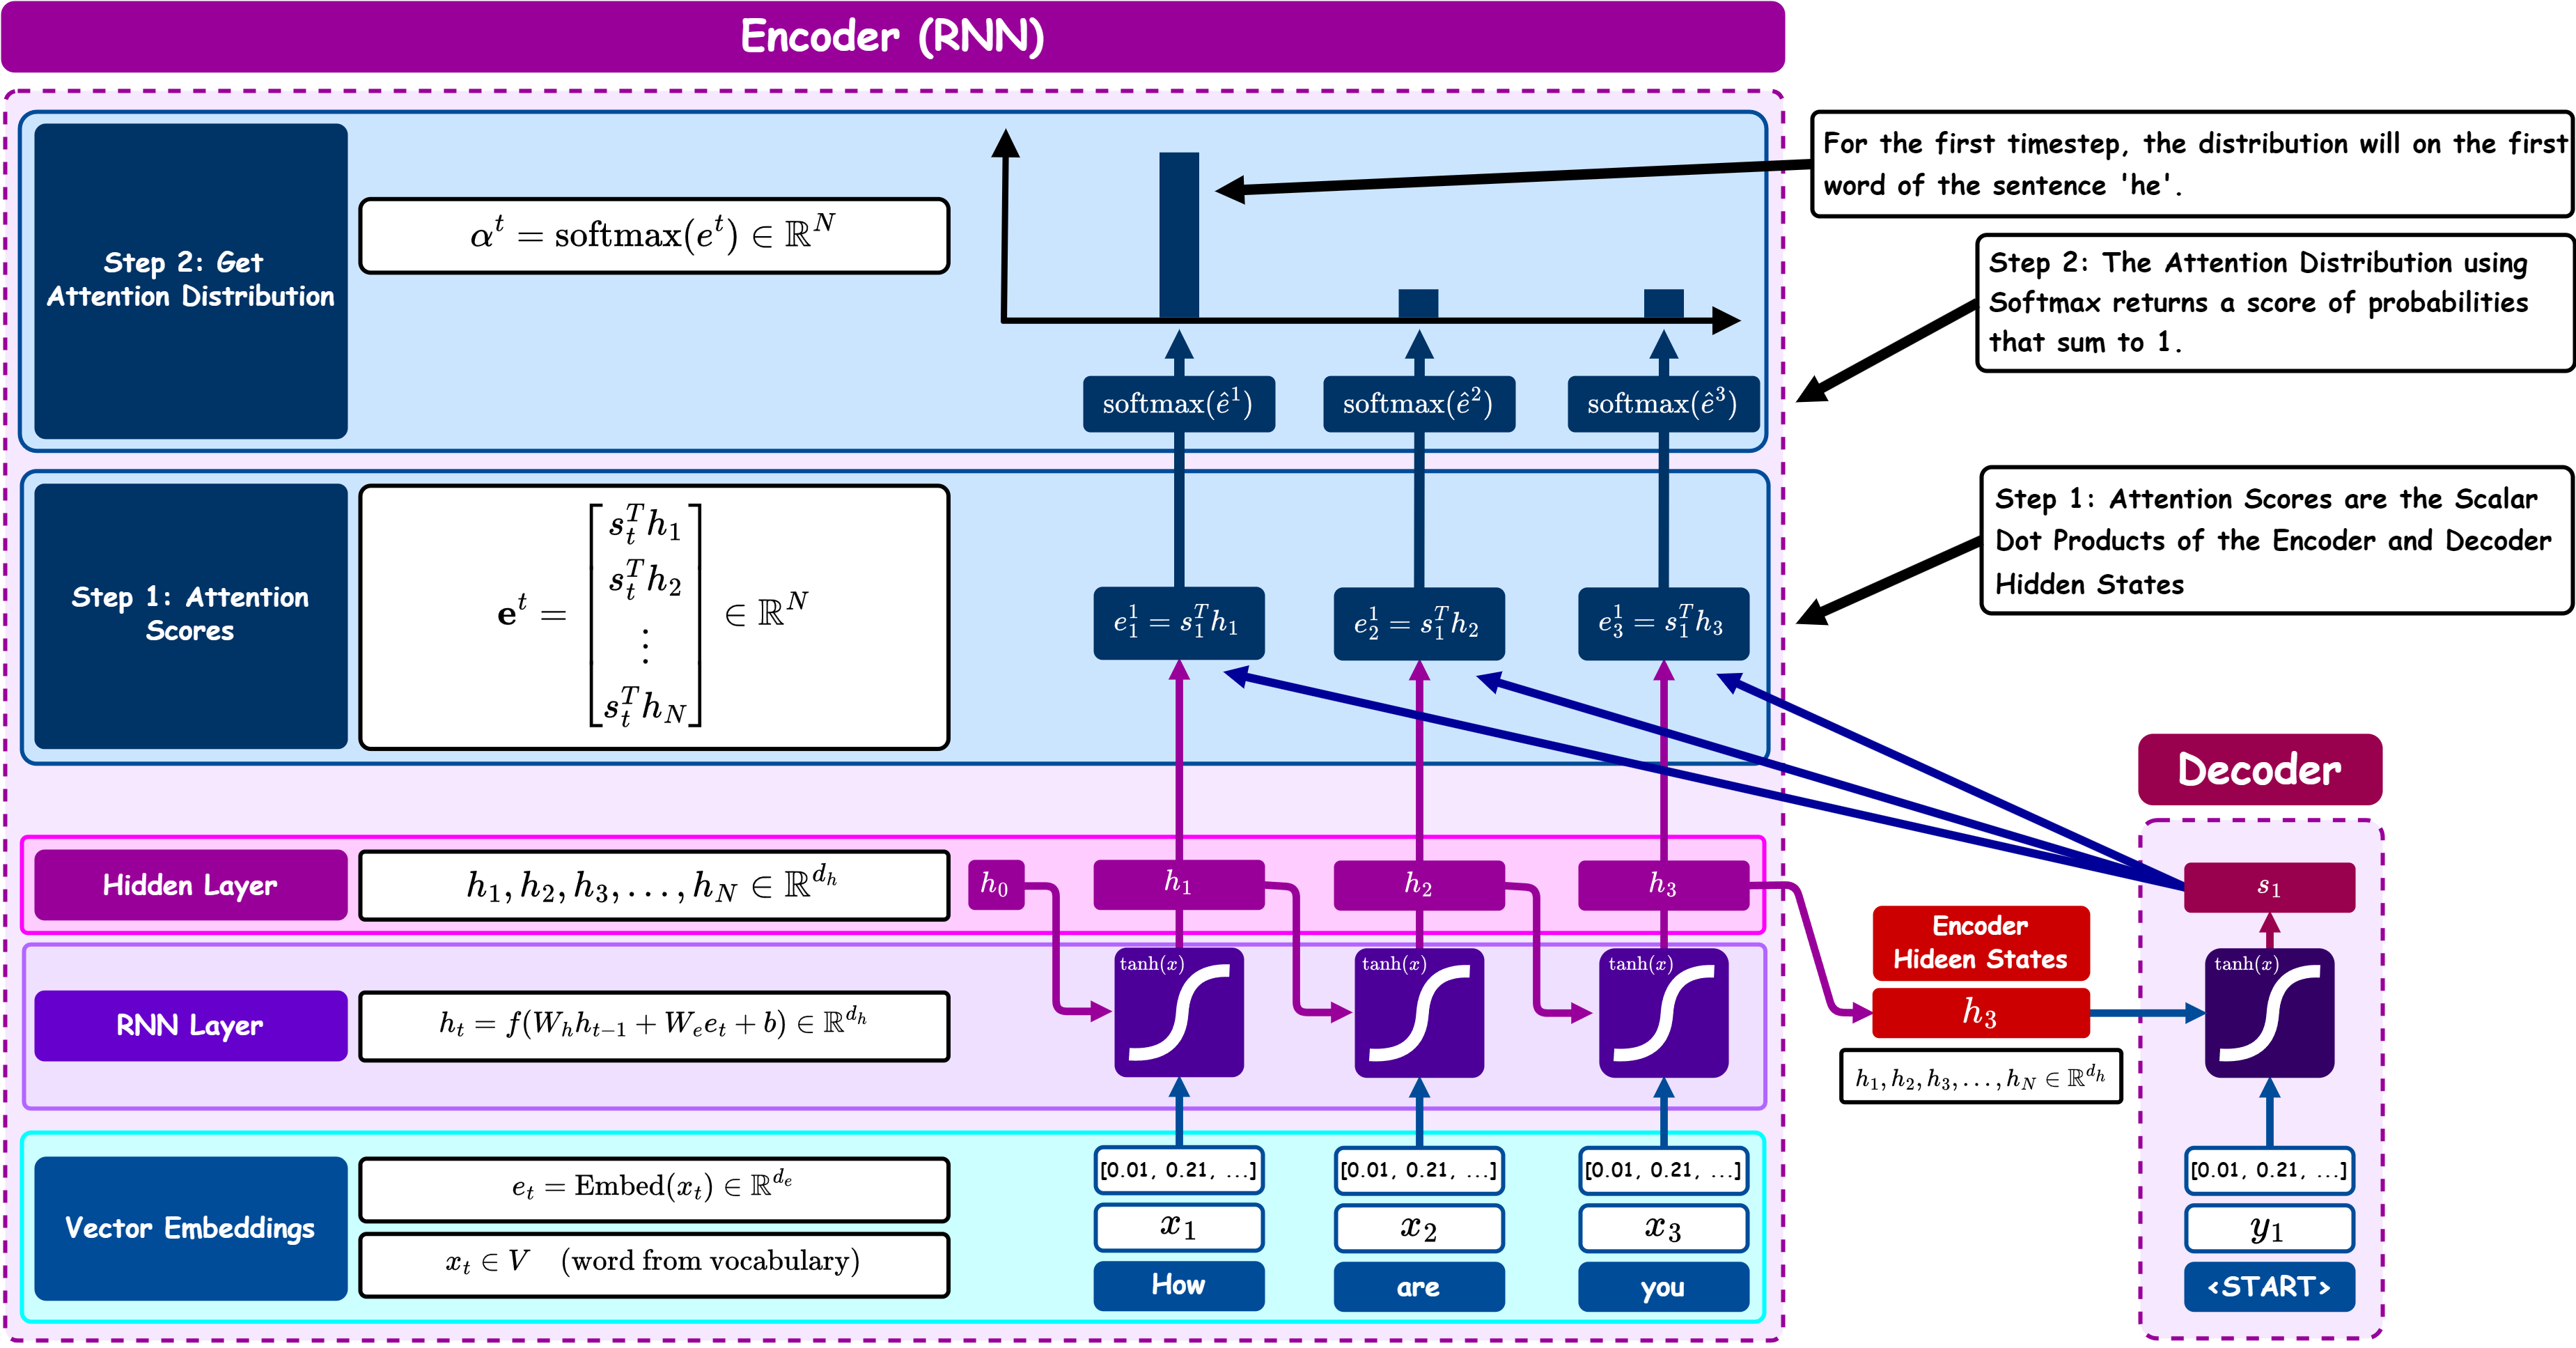

**Step 2: Get Attention Distribution**

Apply softmax to turn scores into probabilities that sum to 1:

$$\alpha^t = \text{softmax}(e^t) \in \mathbb{R}^N$$

This distribution tells us "how much" to focus on each source word.

**Step 3: Compute Attention Output (Context Vector)**

Take a weighted sum of encoder hidden states using the attention distribution:

$$a_t = \sum_{i=1}^{N} \alpha_i^t h_i \in \mathbb{R}^h$$

The attention output $a_t$ primarily contains information from encoder states that received high attention weights.

**Step 4: Combine with Decoder State**

Concatenate the attention output with the decoder hidden state:

$$[a_t; s_t] \in \mathbb{R}^{2h}$$

This combined representation is then used to predict the next target word, just as in the standard seq2seq model.

<br>

***

### **4. Visualizing Attention: Translation Example**

**Source:** "il a m' entarté" (French)  
**Target:** "he hit me with a pie" (English)

When generating each English word, the decoder attends to different French words:

| Decoder Step | Target Word | Primary Attention On |
|---|---|---|
| 1 | "he" | "il" (he) |
| 2 | "hit" | "a" (has), "entarté" (pied) |
| 3 | "me" | "m'" (me) |
| 4 | "with" | "entarté" (pied) |
| 5 | "a" | "entarté" (pied) |
| 6 | "pie" | "entarté" (pied) |

At each step, the attention distribution changes, allowing the decoder to focus on the most relevant parts of the source sentence.

**Alignment for Free:**

By visualizing the attention weights as a heatmap, we can see soft word alignments between source and target languages, essentially showing which source words correspond to which target words. This interpretability is a major advantage of attention.

<br>

***

### **5. Attention Formula Summary**

The attention mechanism follows three core steps:

**1. Compute attention scores** $e \in \mathbb{R}^N$

Multiple methods exist for this (dot product, additive attention, etc.). The dot product method shown here is common.

**2. Apply softmax to get attention distribution** $\alpha$:

$$\alpha = \text{softmax}(e) \in \mathbb{R}^N$$

**3. Take weighted sum to get attention output** $a$ (context vector):

$$a = \sum_{i=1}^{N} \alpha_i h_i \in \mathbb{R}^{d_1}$$

This output is then combined with the decoder state to make predictions.

<br>

***

### **6. Advantages of Neural Machine Translation (NMT)**

Compared to older Statistical Machine Translation (SMT) systems:

**Performance:**
- More fluent and natural translations
- Better use of context
- Better handling of phrase similarities

**Engineering:**
- Single end-to-end neural network (no separate subcomponents to tune)
- No manual feature engineering required
- Same architecture works for all language pairs

**Impact:**

NMT went from experimental research in 2014 to industry standard by 2016. Google Translate, Microsoft Translator, Facebook, Baidu, and others all switched to NMT, achieving dramatic improvements with far less engineering effort than SMT required.

<br>

***

### **7. Remaining Challenges in Machine Translation**

Despite major progress, several difficulties persist:

**Technical Challenges:**
- Out-of-vocabulary words (words not seen during training)
- Domain mismatch between training and test data
- Maintaining coherence over long documents
- Low-resource language pairs (limited training data)

**Linguistic Challenges:**
- Common sense reasoning
- Idiomatic expressions (e.g., "paper jam" → literal translation fails)
- Gender bias in training data leading to stereotyped outputs

**Specialized Settings:**
- Speech translation (longer signals, noise, prosody)
- Simultaneous translation (balancing latency vs. accuracy)

Machine translation has improved dramatically, but it's far from a fully solved problem.

<br>

***

### **8. Research Landscape**

Two major conference series focus exclusively on machine translation:

**WMT (Conference on Machine Translation)**
- Annual workshops/conferences since 2006
- Includes shared tasks and standardized evaluation

**IWSLT (International Conference on Spoken Language Translation)**
- Focuses on speech-to-speech and speech-to-text translation
- Running since 2004

Additionally, all major NLP conferences (ACL, EMNLP, NAACL, etc.) have dedicated MT tracks, reflecting the field's ongoing importance and active research community.